# Sampling in Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# importing the dataset
coffee_df = pd.read_feather('./datasets/coffee_ratings_full.feather')
coffee_df.head()

,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,89.92,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,89.75,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0.0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,89.00,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2.0,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,88.83,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


## Sampling using the `df.sample()` method

In [19]:
# Creating a subset from the coffee_df 
points_flvr_pop = coffee_df[["total_cup_points", "flavor"]]

# Creating a sample - selecting 10 randowm rows from above df
points_flvr_smpl = points_flvr_pop.sample(n=10)
print(points_flvr_smpl)

      total_cup_points  flavor
880              81.67    7.42
1222             78.50    6.83
422              83.25    7.67
852              81.83    7.75
746              82.25    7.50
237              84.08    7.75
1160             79.67    7.00
654              82.50    7.75
783              82.08    7.50
1094             80.25    7.33


Notice the rowIDs of the randomly selected rows.

## Population parameters & Sample statistics
- Population parameters - a calculation made on the population dataset
- Point estimate / sample stat - a calculation made onthe sample dataset

In [22]:
# Population stats for flavors
print("Stats for 'flavor' column :")
print(f"Population mean - {coffee_df["flavor"].mean().round(2)}")
print(f"Population mean - {points_flvr_smpl["flavor"].mean().round(2)}")

Stats for 'flavor' column :
Population mean - 7.53
Population mean - 7.45


Note that sample mean is similar BUT NOT identical to population mean.

## Convenience sampling
It is basically collecting data using the easiest method—can result in samples that aren't representative of the population. 

Equivalently, this means findings from the sample are **not generalizable to the population**. 

**EXAMPLE:**<br>
Sampling only the first 10 rows of a dataset instead of the entire dataset. Here, each row in the sample df will not be an appropriate representation of the overal population dataset -- this will introduce _sample bias_.



In [25]:
print(f"Population mean of points - {coffee_df["total_cup_points"].mean().round(2)}")

print(f"Sample mean of points for first 10 rows - {coffee_df["total_cup_points"].head().mean()}")

Population mean of points - 82.15
Sample mean of points for first 10 rows - 89.616


Thus, there was significant difference between the actual population mean than that of the sample mean. this is called **sample bias**.

### Visualizing Convenience bias
Visualizing the distributions of the population (entire dataset) and the sample(first 10 rows) can help determine whether or not the sample is representative of the population.

In [26]:
coffee_df["total_cup_points"].describe()

count    1338.000000
mean       82.151203
std         2.686862
min        59.830000
25%        81.102500
50%        82.500000
75%        83.670000
max        90.580000
Name: total_cup_points, dtype: float64

_From above stats of the `total_cup_points` column, Lets consider bins range form 59 - 92_

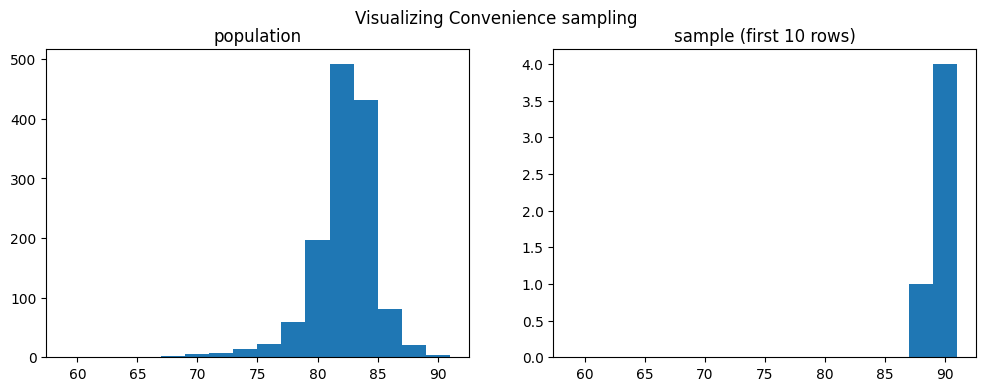

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
ax1.hist(data = coffee_df , x="total_cup_points" , bins=np.arange(59,92,2))
ax1.set_title("population")

ax2.hist(data = coffee_df.head() , x="total_cup_points", bins=np.arange(59,92,2))
ax2.set_title("sample (first 10 rows)")

fig.suptitle("Visualizing Convenience sampling - introduces ")
plt.show()

We can see how skewed the distribution was for the sample data , hence the large mean value.

This can be resolved by taking _n_ random values from the entire population dataset -- this will closely resemble the overall population dataset.

### Visualizing random sample bias

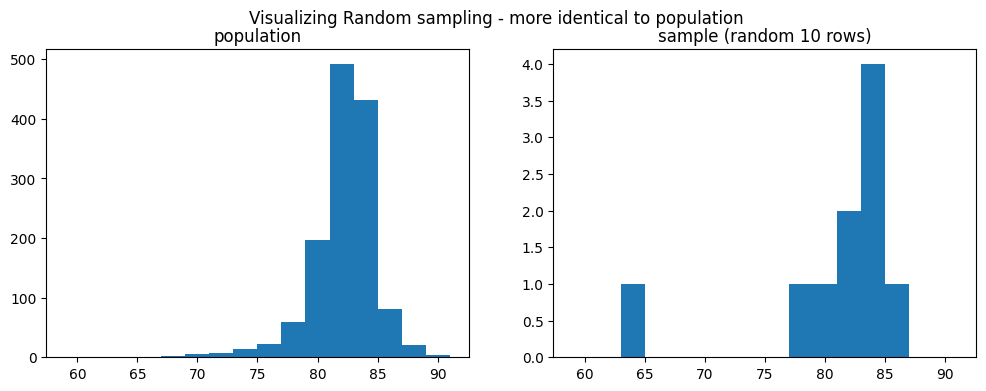

In [49]:
# Creating a sample of 10 random rows from the population
coffee_smpl = coffee_df.sample(n=10)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
ax1.hist(data = coffee_df , x="total_cup_points" , bins=np.arange(59,92,2))
ax1.set_title("population")

ax2.hist(data = coffee_smpl , x="total_cup_points", bins=np.arange(59,92,2))
ax2.set_title("sample (random 10 rows)")

fig.suptitle("Visualizing Random sampling - more identical to population")
plt.show()

### Pseudo-random Number generation

The first random no. is called 'seed value'. The next subsequent 'random' no. is generated from its previous 'random' no. The primary reasons for setting a seed include:<br>
- Reproducibility: the most common use case. By using the same seed, you and **others can recreate the exact same results**. This is essential for scientific research, where findings must be independently verifiable.

- Debugging and Testing: When a bug occurs during a random process (like a simulation), a fixed seed allows developers to run the code again under the exact same conditions to identify the error.

- Machine Learning Consistency: Seeds are used to ensure that data splitting (training/test sets), weight initialization, and shuffling remain identical across multiple runs. This allows for fair comparisons when testing different model architectures or hyperparameters.

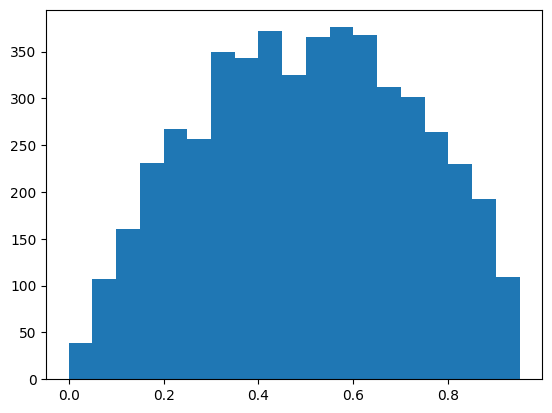

In [ ]:
import random
# Setting the initial seed value - this will make the 'random' values reproducible
np.random.seed(1)
random_sample = np.random.beta(a=2, b=2, size=5000)
plt.hist(random_sample, bins = np.arange(0,1,0.05))
plt.show()

(array([ 2.,  2.,  5., 13.,  9., 14., 10., 16., 10.,  7.,  3.,  3.,  1.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ,
        6.5]),
 <BarContainer object of 13 artists>)

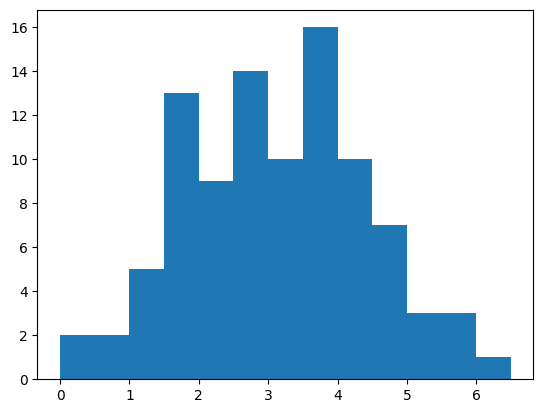

In [67]:
# a random normal distribution with 
random_normal_smple = np.random.normal(loc= 3, scale=1.5, size= 100)
plt.hist(random_normal_smple, bins=np.arange(0,7,0.5))

## Simple Random Sampling
Each row of the population has an equal chance of being seleted. This method is ideal for a quick, unbiased sampling. 

However this does NOT guarantee the winners will represent the whole crowd fairly.

The drawbacks of SRS:
1. **Risk of Underrepresentation (The "Small Group" Problem)** : If your dataset contains a small but important minority group, SRS might miss them entirely or pick so few that they aren't statistically significant.
2. **High Variance in Results** : Because SRS relies entirely on chance, two different random samples from the same population can yield wildly different results (high sampling error), especially with smaller sample sizes.

Hence other sampling methods such as Systematic / Stratified samping are used to sampel the population dataset.

## Systematic sampling
Data is selected using a regular pattern, such as choosing every $n^{th}$ item, which is quick but can be affected by hidden patterns.

In [69]:
# defining sample
sample_size = 5
pop_size = len(coffee_df)
pop_size
# Calculating the interval -- absolute int 
interval = pop_size//sample_size
interval

267

The resulting sample is a slice of every $267^{th}$ row of the population dataset:

In [70]:
# Dividing the dataset based on ontervals
coffee_df.iloc[::interval]

,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
267,83.92,Arabica,federacion nacional de cafeteros,Colombia,NaN,NaN,NaN,01-1969,federacion nacional de cafeteros,NaN,...,None,1.0,"March 11th, 2016",Almacafé,e493c36c2d076bf273064f7ac23ad562af257a25,70d3c0c26f89e00fdae6fb39ff54f0d2eb1c38ab,m,NaN,NaN,NaN
534,82.92,Arabica,consejo salvadoreño del café,El Salvador,santa josefita,1-198,beneficio cuzcachapa,09-030-273,soc. coop. cuzcachapa de r.l.,1350,...,Green,1.0,"August 28th, 2018",Salvadoran Coffee Council,3d4987e3b91399dbb3938b5bdf53893b6ef45be1,27b21e368fb8291cbea02c60623fe6c98f84524d,m,1350.0,1350.0,1350.0
801,82.00,Arabica,"lin, che-hao krude 林哲豪",Taiwan,"you siang coffee farmtainan, taiwan 台灣台南優香咖啡",NaN,"you siang coffee farmtainan, taiwan 台灣台南優香咖啡",Taiwan,"red on tree co., ltd.",600m,...,Green,0.0,"July 22nd, 2015",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,600.0,600.0,600.0
1068,80.50,Arabica,cqi taiwan icp cqi台灣合作夥伴,Taiwan,王秋金,1,non,NaN,王秋金,50,...,Blue-Green,0.0,"December 8th, 2018",Blossom Valley International,fc45352eee499d8470cf94c9827922fb745bf815,de73fc9412358b523d3a641501e542f31d2668b0,m,50.0,50.0,50.0
1335,77.17,Robusta,james moore,United States,fazenda cazengo,NaN,cafe cazengo,NaN,global opportunity fund,795 meters,...,NaN,6.0,"December 23rd, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,795.0,795.0,795.0


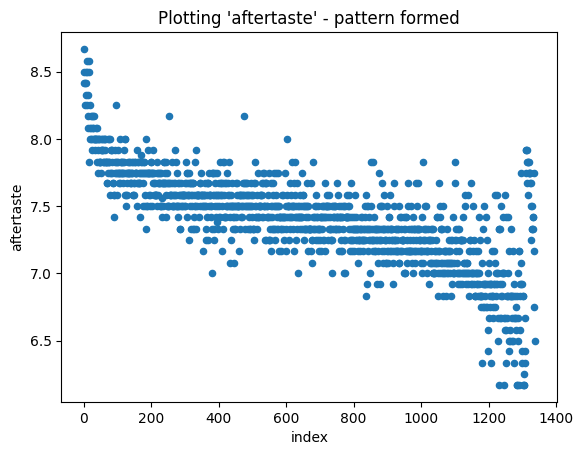

In [80]:
coffee_ratings_with_id = coffee_df.reset_index()
coffee_ratings_with_id.plot(x="index", y="aftertaste", kind="scatter")

plt.title("Plotting 'aftertaste' - pattern formed")

plt.show()

Earlier columns have higher aftertaste scores as compared to later rows.

In [74]:
coffee_df

,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,89.92,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,89.75,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0.0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,89.00,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2.0,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,88.83,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,78.75,Robusta,luis robles,Ecuador,robustasa,Lavado 1,our own lab,NaN,robustasa,NaN,...,Blue-Green,1.0,"January 18th, 2017",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,NaN,NaN,NaN
1334,78.08,Robusta,luis robles,Ecuador,robustasa,Lavado 3,own laboratory,NaN,robustasa,40,...,Blue-Green,0.0,"January 18th, 2017",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,40.0,40.0,40.0
1335,77.17,Robusta,james moore,United States,fazenda cazengo,NaN,cafe cazengo,NaN,global opportunity fund,795 meters,...,NaN,6.0,"December 23rd, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,795.0,795.0,795.0
1336,75.08,Robusta,cafe politico,India,NaN,NaN,NaN,14-1118-2014-0087,cafe politico,NaN,...,Green,1.0,"August 25th, 2015",Specialty Coffee Association,ff7c18ad303d4b603ac3f8cff7e611ffc735e720,352d0cf7f3e9be14dad7df644ad65efc27605ae2,m,NaN,NaN,NaN


## Stratified random sampling

Grouping data before sampling to maintain subgroup proportions. This is useful when the analysis requires representative samples from each subgroup.

By grouping & then sampling, the size of each group in the sample is representative of the size of the sample in the population.

## Equal Counts Stratified Sampling

Sampling equal numbers from each subgroup, regardless of their size in the population. This is implemented by changing the `.sample` method's argument from `frac` to `n`, ensuring each country contributed the same number of samples.

Equal counts stratified sampling is the appropriate technique if each subgroup needs to have equal weight in the analysis.

## Weighted random sampling

Weighted Random Sampling: Adjusting the probability of each row being sampled based on a set of weights. This technique allows for more flexibility, such as increasing the representation of underrepresented groups in the sample.